In [124]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [125]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout

In [126]:
import os
import pandas as pd

folder_path = r"/content/sample_data" # This is folder inside colab as it cant understand local machine data path

files = os.listdir(folder_path)
print("Files found:", files)

file_name = "mnist_train_small.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

Files found: ['anscombe.json', 'README.md', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_test.csv', 'mnist_train_small.csv']


In [127]:
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [128]:
df.shape

(19999, 785)

In [129]:
col = [f"{i}" for i in range(784)]

In [130]:
col.insert(0, "label")

In [131]:
df.columns = col

In [132]:
df.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
Model = Sequential()
Model.add(Dense(64, activation='relu', input_dim=784))
Model.add(Dense(32, activation='relu'))
Model.add(Dense(15, activation='relu'))
Model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [134]:
Model.compile(optimizer = keras.optimizers.Adam(learning_rate=0.001), loss = keras.losses.sparse_categorical_crossentropy , metrics=['accuracy']) # we use sparse_cat_cross_entropy because we dont wanna OHE our output column

In [135]:
Model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 15)             │           495 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,975 (206.93 KB)

 Trainable params: 52,975 (206.93 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
hist = Model.fit(df.drop("label", axis=1), df["label"], epochs=32, validation_split=0.2)

Epoch 1/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2897 - loss: 2.4417 - val_accuracy: 0.5285 - val_loss: 1.4275
Epoch 2/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5857 - loss: 1.2050 - val_accuracy: 0.6587 - val_loss: 1.0260
Epoch 3/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6973 - loss: 0.9079 - val_accuracy: 0.7215 - val_loss: 0.8713
Epoch 4/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7444 - loss: 0.7228 - val_accuracy: 0.7682 - val_loss: 0.6840
Epoch 5/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8349 - loss: 0.5718 - val_accuracy: 0.8550 - val_loss: 0.5736
Epoch 6/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8767 - loss: 0.4681 - val_accuracy: 0.8695 - val_loss: 0.4930
Epoch 7/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9037 - loss: 0.3893 - val_accuracy: 0.8875 - val_loss: 0.4582
Epoch 8/32
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9172 - loss: 0.3252 - val_accuracy: 0.

In [137]:
df_test = pd.read_csv(os.path.join(folder_path, "mnist_test.csv"))

In [138]:
x_test = df.drop(columns=["label"])
y_test = df["label"]

In [139]:
y_pred = Model.predict(x_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 963us/step


In [140]:
y_pred = y_pred.argmax(axis=1)

In [141]:
y_pred[:5]

array([5, 7, 9, 5, 2])

In [142]:
hist.history.items()

dict_items([('accuracy', [0.2897056043148041, 0.5857241153717041, 0.6972935795783997, 0.744359016418457, 0.8349272012710571, 0.8766797780990601, 0.9036814570426941, 0.9172448515892029, 0.9303081631660461, 0.9424338936805725, 0.9461841583251953, 0.9554972052574158, 0.9556222558021545, 0.9583098888397217, 0.9594974517822266, 0.9648727774620056, 0.9692480564117432, 0.971123218536377, 0.9673729538917542, 0.9703731536865234, 0.9769360423088074, 0.9779361486434937, 0.9760609865188599, 0.9809988141059875, 0.9807487726211548, 0.9788736701011658, 0.9803112745285034, 0.9813113212585449, 0.9863741397857666, 0.9824364185333252, 0.9821863770484924, 0.9867491722106934]), ('loss', [2.441685914993286, 1.205021858215332, 0.9078813791275024, 0.722795307636261, 0.5717675089836121, 0.4681473672389984, 0.38925597071647644, 0.32517480850219727, 0.2855255901813507, 0.23407800495624542, 0.21312293410301208, 0.18022972345352173, 0.17897243797779083, 0.16516588628292084, 0.15993249416351318, 0.14216408133506775

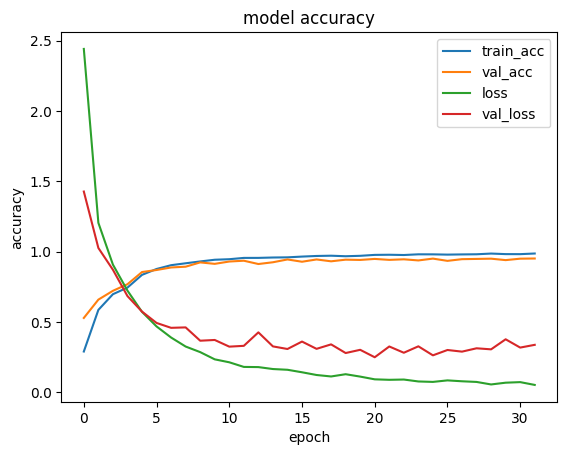

In [143]:
from matplotlib import legend
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['train_acc', 'val_acc', 'loss', 'val_loss'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

In [144]:
from sklearn.metrics import classification_report, accuracy_score
c_r_ = classification_report(y_test, y_pred)

In [145]:
c_r_

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99      1962\n           1       1.00      0.98      0.99      2243\n           2       0.98      0.97      0.98      1989\n           3       0.98      0.97      0.97      2021\n           4       0.98      0.99      0.99      1924\n           5       0.99      0.96      0.97      1761\n           6       0.98      1.00      0.99      2038\n           7       0.99      0.98      0.99      2126\n           8       0.94      0.99      0.96      1912\n           9       0.98      0.98      0.98      2023\n\n    accuracy                           0.98     19999\n   macro avg       0.98      0.98      0.98     19999\nweighted avg       0.98      0.98      0.98     19999\n'

In [146]:
acc = accuracy_score(y_test, y_pred)
acc

0.9815990799539978

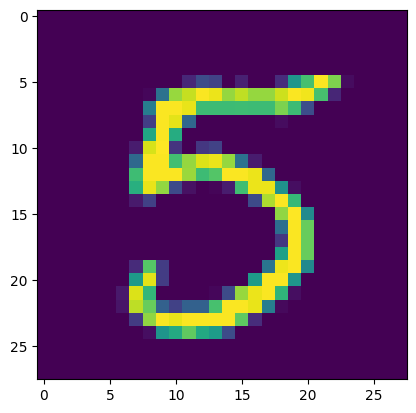

In [147]:
import matplotlib.pyplot as plt
plt.imshow(x_test.iloc[0, :].values.reshape(28, 28))
#

In [148]:
y_pred[0]

np.int64(5)